In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
RND = 42

In [2]:
path = r"star_classification.csv"
df = pd.read_csv(path)
print("rows,cols:", df.shape)

rows,cols: (100000, 18)


In [5]:
df.dtypes

obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class           object
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object

In [7]:
target = "class"
X = df.drop(columns=[target], errors="ignore").copy()
y = df[target].copy()
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, y, test_size=0.2, random_state=RND, stratify=y)
train_df = Xtrain.copy()
train_df[target] = Ytrain.values
print("train shape", Xtrain.shape, "test shape", Xtest.shape)
print(Ytrain.value_counts(normalize=True))

train shape (80000, 17) test shape (20000, 17)
class
GALAXY    0.594450
STAR      0.215938
QSO       0.189612
Name: proportion, dtype: float64


In [9]:
colsToNull = [c for c in ["u","g","r","i","z"] if c in Xtrain.columns]
for col in colsToNull:
    Xtrain.loc[Xtrain.sample(frac=0.15, random_state=RND).index, col] = np.nan

In [11]:
print(Xtrain.isnull().sum())

obj_ID             0
alpha              0
delta              0
u              12000
g              12000
r              12000
i              12000
z              12000
run_ID             0
rerun_ID           0
cam_col            0
field_ID           0
spec_obj_ID        0
redshift           0
plate              0
MJD                0
fiber_ID           0
dtype: int64


In [13]:
dupCount = Xtrain.duplicated().sum()
print("Duplicated rows in Xtrain:", dupCount)

Duplicated rows in Xtrain: 0


In [15]:
numericCols = Xtrain.select_dtypes(include=[np.number]).columns.tolist()
outlierSummary = {}
for col in numericCols:
    Q1 = Xtrain[col].quantile(0.25)
    Q3 = Xtrain[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    lowerCount = int((Xtrain[col] < lower).sum())
    upperCount = int((Xtrain[col] > upper).sum())
    outlierSummary[col] = {"Lower Outliers": lowerCount, "Upper Outliers": upperCount, "Total Outliers": lowerCount + upperCount}
outlierTable = pd.DataFrame(outlierSummary).T
print(outlierTable)

             Lower Outliers  Upper Outliers  Total Outliers
obj_ID                    0               0               0
alpha                     0               0               0
delta                     0               0               0
u                        33               7              40
g                        52              17              69
r                        79              12              91
i                       110              23             133
z                       167              47             214
run_ID                    0               0               0
rerun_ID                  0               0               0
cam_col                   0               0               0
field_ID                  0            4253            4253
spec_obj_ID               0               0               0
redshift                  0            7163            7163
plate                     0               0               0
MJD                       0             

In [17]:
numericFeatures = Xtrain.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categoricalFeatures = Xtrain.select_dtypes(include=["object", "category"]).columns.tolist()
numTrainBefore = Xtrain[numericFeatures].copy()
meanBefore = numTrainBefore.mean()
varBefore  = numTrainBefore.var()
print("\nNumeric columns - before filling nulls")
print("Mean", meanBefore)
print("\nVariancn", varBefore)


Numeric columns - before filling nulls
Mean:
 obj_ID         1.237665e+18
alpha          1.775022e+02
delta          2.413677e+01
u              2.192662e+01
g              2.048104e+01
r              1.964207e+01
i              1.907989e+01
z              1.861685e+01
run_ID         4.481136e+03
rerun_ID       3.010000e+02
cam_col        3.509275e+00
field_ID       1.865308e+02
spec_obj_ID    5.786838e+18
redshift       5.758442e-01
plate          5.139635e+03
MJD            5.559058e+04
fiber_ID       4.487251e+02
dtype: float64

Variance:
 obj_ID         7.123104e+25
alpha          9.302780e+03
delta          3.857631e+02
u              1.481862e+03
g              1.480538e+03
r              3.455680e+00
i              3.098412e+00
z              1.478943e+03
run_ID         3.861478e+06
rerun_ID       0.000000e+00
cam_col        2.518645e+00
field_ID       2.228485e+04
spec_obj_ID    1.104453e+37
redshift       5.320634e-01
plate          8.712504e+06
MJD            3.267704e+06
fi

In [19]:
numMeans = Xtrain[numericFeatures].mean()
Xtrain.loc[:, numericFeatures] = Xtrain[numericFeatures].fillna(numMeans)
Xtest.loc[:, numericFeatures]  = Xtest[numericFeatures].fillna(numMeans)
meanAfter = Xtrain[numericFeatures].mean()
varAfter  = Xtrain[numericFeatures].var()
print("\nNumeric columns - after filling nulls")
print("Mean", meanAfter)
print("\nVariancn", varAfter)


Numeric columns - after filling nulls
Mean:
 obj_ID         1.237665e+18
alpha          1.775022e+02
delta          2.413677e+01
u              2.192662e+01
g              2.048104e+01
r              1.964207e+01
i              1.907989e+01
z              1.861685e+01
run_ID         4.481136e+03
rerun_ID       3.010000e+02
cam_col        3.509275e+00
field_ID       1.865308e+02
spec_obj_ID    5.786838e+18
redshift       5.758442e-01
plate          5.139635e+03
MJD            5.559058e+04
fiber_ID       4.487251e+02
dtype: float64

Variance:
 obj_ID         7.123104e+25
alpha          9.302780e+03
delta          3.857631e+02
u              1.259580e+03
g              1.258454e+03
r              2.937321e+00
i              2.633645e+00
z              1.257099e+03
run_ID         3.861478e+06
rerun_ID       0.000000e+00
cam_col        2.518645e+00
field_ID       2.228485e+04
spec_obj_ID    1.104453e+37
redshift       5.320634e-01
plate          8.712504e+06
MJD            3.267704e+06
fib

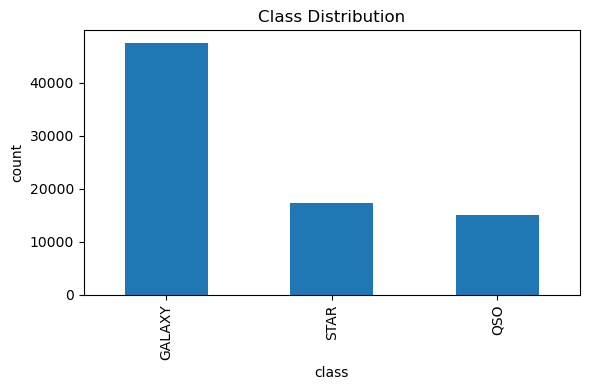

In [21]:
TrainDf = Xtrain.copy()
TrainDf[target] = Ytrain.values
plt.figure(figsize=(6,4))
TrainDf[target].value_counts().plot(kind="bar")
plt.xlabel("class")
plt.ylabel("count")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

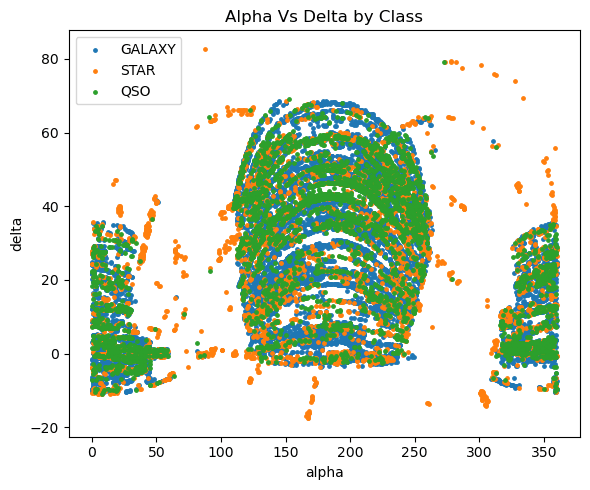

In [22]:
if {"alpha", "delta", target}.issubset(TrainDf.columns):
    SampleN = min(len(TrainDf), 20000)
    SampleDf = TrainDf.sample(n=SampleN, random_state=RND)
    plt.figure(figsize=(6,5))
    for Label in SampleDf[target].unique():
        Mask = SampleDf[target] == Label
        plt.scatter(SampleDf.loc[Mask, "alpha"], SampleDf.loc[Mask, "delta"], s=6, label=Label)
    plt.xlabel("alpha")
    plt.ylabel("delta")
    plt.title("Alpha Vs Delta by Class")
    plt.legend()
    plt.tight_layout()
    plt.show()

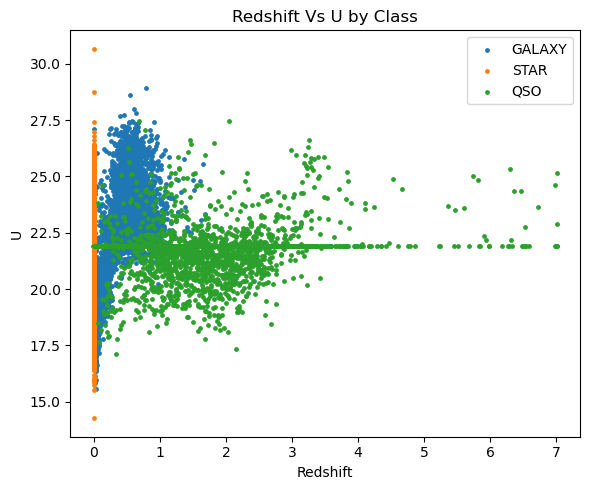

In [24]:
if {"redshift", "u", target}.issubset(TrainDf.columns):
    SampleN = min(len(TrainDf), 20000)
    SampleDf = TrainDf.sample(n=SampleN, random_state=RND)
    plt.figure(figsize=(6,5))
    for Label in SampleDf[target].unique():
        Mask = SampleDf[target] == Label
        plt.scatter(SampleDf.loc[Mask, "redshift"], SampleDf.loc[Mask, "u"], s=6, label=Label)
    plt.xlabel("Redshift")
    plt.ylabel("U")
    plt.title("Redshift Vs U by Class")
    plt.legend()
    plt.tight_layout()
    plt.show()

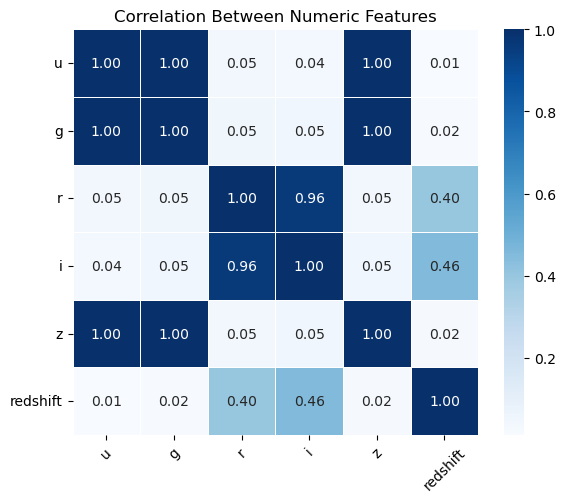

In [27]:
NumericFeaturesForCorr = ["u","g","r","i","z","redshift"]
CorrMatrix = TrainDf[NumericFeaturesForCorr].corr()

plt.figure(figsize=(6,5))
sns.heatmap(CorrMatrix, annot=True, cmap="Blues", fmt=".2f", square=True, linewidths=0.5, cbar=True)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

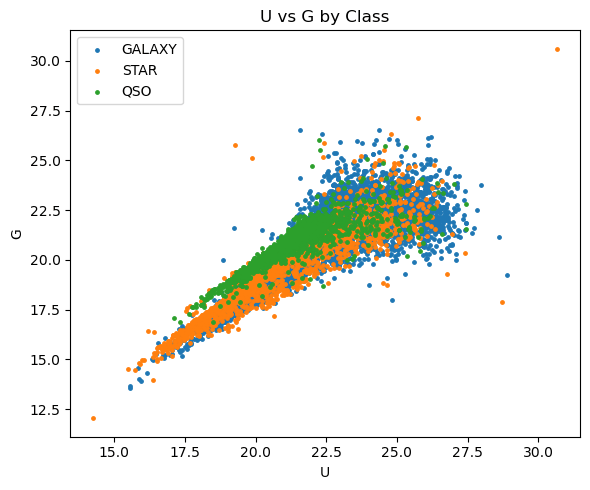

In [29]:
if {"u", "g", target}.issubset(TrainDf.columns):
    SampleN = min(len(TrainDf), 20000)
    SampleDf = TrainDf.sample(n=SampleN, random_state=RND)
    plt.figure(figsize=(6,5))
    for Label in SampleDf[target].unique():
        Mask = SampleDf[target] == Label
        plt.scatter(SampleDf.loc[Mask, "u"], SampleDf.loc[Mask, "g"], s=6, label=Label)
    plt.xlabel("U")
    plt.ylabel("G")
    plt.title("U vs G by Class")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [31]:
XtrainEncoded = pd.get_dummies(Xtrain, columns=categoricalFeatures, drop_first=False)
XtestEncoded  = pd.get_dummies(Xtest,  columns=categoricalFeatures, drop_first=False)
XtestEncoded = XtestEncoded.reindex(columns=XtrainEncoded.columns, fill_value=0)
XtrainEncoded = XtrainEncoded.apply(pd.to_numeric, errors='coerce').fillna(0)
XtestEncoded = XtestEncoded.apply(pd.to_numeric, errors='coerce').fillna(0)
print("X train encoded shape:", XtrainEncoded.shape)
print("X test encoded shape:", XtestEncoded.shape)

X train encoded shape: (80000, 17)
X test encoded shape: (20000, 17)


In [33]:
le = LabelEncoder()
Ytrain = pd.Series(le.fit_transform(Ytrain.astype(str)), index=Ytrain.index)
Ytest = pd.Series(le.transform(Ytest.astype(str)), index=Ytest.index)
classes = list(le.classes_)
scaler = StandardScaler()
XtrainReady = scaler.fit_transform(XtrainEncoded)
XtestReady  = scaler.transform(XtestEncoded)

In [35]:
Ytrain.dtypes

dtype('int32')

In [37]:
print("Grid Search Random Forest")
RfParams={"n_estimators":[300,500],"max_depth":[15,20],"min_samples_split":[20,40],"min_samples_leaf":[10,30],"max_features":[0.3,0.5]}
RfGrid=GridSearchCV(RandomForestClassifier(random_state=RND,n_jobs=-1),RfParams,cv=3,scoring="f1_macro",n_jobs=-1)
RfGrid.fit(XtrainReady,Ytrain)
BestRf=RfGrid.best_estimator_
print("Best RF Params:",RfGrid.best_params_)
print("Best RF F1 Macro:",f"{RfGrid.best_score_:.4f}")

Grid Search Random Forest
Best RF Params: {'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 500}
Best RF F1 Macro: 0.9709


In [38]:
print("Grid Search Logistic Regression")
LrParams={"C":[0.1,1,10,50],"solver":["liblinear","lbfgs"]}
LrGrid=GridSearchCV(LogisticRegression(max_iter=2000,random_state=RND),LrParams,cv=5,scoring="f1_macro",n_jobs=-1)
LrGrid.fit(XtrainReady,Ytrain)
BestLr=LrGrid.best_estimator_
print("Best LR Params:",LrGrid.best_params_)
print("Best LR F1 Macro:",f"{LrGrid.best_score_:.4f}")


Grid Search Logistic Regression
Best LR Params: {'C': 50, 'solver': 'lbfgs'}
Best LR F1 Macro: 0.9518


In [39]:
print("Grid Search SVM")
SvmParams={"C":[0.5,1,5],"kernel":["rbf"],"gamma":["scale","auto"]}
SvmGrid=GridSearchCV(SVC(random_state=RND,probability=True),SvmParams,cv=3,scoring="f1_macro",n_jobs=-1)
SvmGrid.fit(XtrainReady,Ytrain)
BestSvm=SvmGrid.best_estimator_
print("Best SVM Params:",SvmGrid.best_params_)
print("Best SVM F1 Macro:",f"{SvmGrid.best_score_:.4f}")


Grid Search SVM
Best SVM Params: {'C': 5, 'gamma': 'auto', 'kernel': 'rbf'}
Best SVM F1 Macro: 0.9513


In [40]:
for Name,Model in [("Random Forest",BestRf),("Logistic Regression",BestLr),("SVM",BestSvm)]:
    YpredTuned=Model.predict(XtestReady)
    print("\n",Name)
    print("Accuracy:",accuracy_score(Ytest,YpredTuned))
    print(classification_report(Ytest,YpredTuned,target_names=classes))


 Random Forest
Accuracy: 0.98025
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000


 Logistic Regression
Accuracy: 0.964
              precision    recall  f1-score   support

      GALAXY       0.96      0.98      0.97     11889
         QSO       0.95      0.88      0.92      3792
        STAR       0.97      1.00      0.99      4319

    accuracy                           0.96     20000
   macro avg       0.96      0.95      0.96     20000
weighted avg       0.96      0.96      0.96     20000


 SVM
Accuracy: 0.96605
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.97     11889
         QSO       0.97      0.90

In [41]:
rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=30, min_samples_split=40, max_depth=20, max_features=0.3, random_state=RND, n_jobs=-1)
rf.fit(XtrainReady, Ytrain)
Ypred = rf.predict(XtestReady)
Yproba = rf.predict_proba(XtestReady)
YtestBin = label_binarize(Ytest, classes=range(len(classes)))
roc = roc_auc_score(YtestBin, Yproba, average="macro", multi_class="ovr")
print("Random Forest results")
print("Accuracy:", accuracy_score(Ytest, Ypred))
print(classification_report(Ytest, Ypred, target_names=classes))
print("AUC:", roc)

Random Forest results
Accuracy: 0.9763
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.98      1.00      0.99      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000

AUC: 0.9951792674877749


In [42]:
lr = LogisticRegression(solver="lbfgs", C=50.0, max_iter=2000, random_state=RND)
lr.fit(XtrainReady, Ytrain)
YpredLr = lr.predict(XtestReady)
YprobaLr = lr.predict_proba(XtestReady)
YtestBinLr = label_binarize(Ytest, classes=range(len(classes)))
rocLr = roc_auc_score(YtestBinLr, YprobaLr, average="macro", multi_class="ovr")
print("Logistic Regression results")
print("Accuracy:", accuracy_score(Ytest, YpredLr))
print(classification_report(Ytest, YpredLr, target_names=classes))
print("AUC:", rocLr)

Logistic Regression results
Accuracy: 0.964
              precision    recall  f1-score   support

      GALAXY       0.96      0.98      0.97     11889
         QSO       0.95      0.88      0.92      3792
        STAR       0.97      1.00      0.99      4319

    accuracy                           0.96     20000
   macro avg       0.96      0.95      0.96     20000
weighted avg       0.96      0.96      0.96     20000

AUC: 0.9895026417375332


In [43]:
svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RND)
svm.fit(XtrainReady, Ytrain)
YpredSvm = svm.predict(XtestReady)
YprobaSvm = svm.predict_proba(XtestReady)
YtestBinSvm = label_binarize(Ytest, classes=range(len(classes)))
rocSvm = roc_auc_score(YtestBinSvm, YprobaSvm, average="macro", multi_class="ovr")
print("SVM results")
print("Accuracy:", accuracy_score(Ytest, YpredSvm))
print(classification_report(Ytest, YpredSvm, target_names=classes))
print("AUC:", rocSvm)

SVM results
Accuracy: 0.9566
              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.96     11889
         QSO       0.97      0.88      0.93      3792
        STAR       0.95      0.98      0.96      4319

    accuracy                           0.96     20000
   macro avg       0.96      0.94      0.95     20000
weighted avg       0.96      0.96      0.96     20000

AUC: 0.9879186745237322


In [44]:
print("Confusion matrix Random foresn", confusion_matrix(Ytest, Ypred))
print("Confusion matrix Logistic regression", confusion_matrix(Ytest, YpredLr))
print("Confusion matrix Svn", confusion_matrix(Ytest, YpredSvm))

Confusion matrix Random forest:
 [[11687   116    86]
 [  272  3520     0]
 [    0     0  4319]]
Confusion matrix Logistic regression:
 [[11612   158   119]
 [  441  3351     0]
 [    1     1  4317]]
Confusion matrix Svm:
 [[11560    98   231]
 [  436  3348     8]
 [   95     0  4224]]


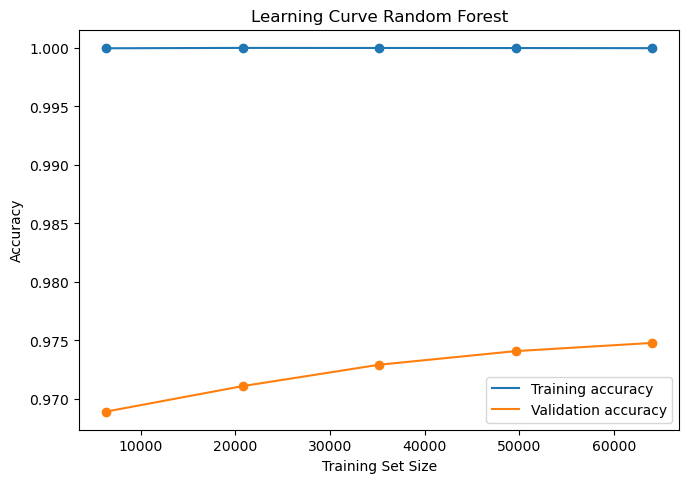

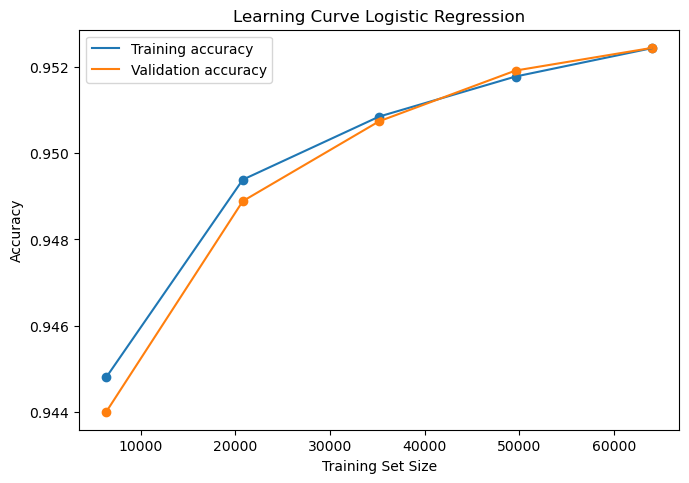

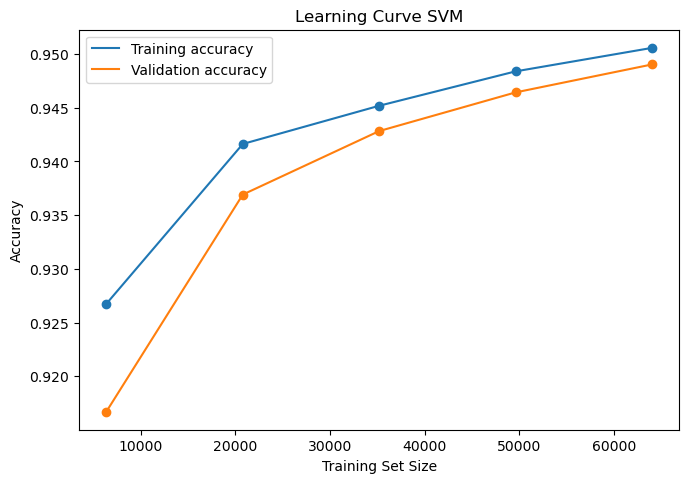

In [48]:
def plotLearningCurve(model, X, y, title):
    trainSizes, trainScores, validScores = learning_curve(model, X, y, cv=5, scoring="accuracy", n_jobs=1, train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=42)
    trainMean = trainScores.mean(axis=1)
    validMean = validScores.mean(axis=1)
    fig = plt.figure(figsize=(6,4))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.scatter(trainSizes, trainMean)
    ax.scatter(trainSizes, validMean)
    ax.plot(trainSizes, trainMean, label="Training accuracy")
    ax.plot(trainSizes, validMean, label="Validation accuracy")
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend()
    plt.show()

plotLearningCurve(RandomForestClassifier(random_state=RND), XtrainReady, Ytrain, title="Learning Curve Random Forest")
plotLearningCurve(LogisticRegression(max_iter=2000), XtrainReady, Ytrain, title="Learning Curve Logistic Regression")
plotLearningCurve(SVC(probability=True), XtrainReady, Ytrain, title="Learning Curve SVM")